In [1]:
!pip install torch torchvision torchaudio
import torch
import torch.nn as nn
from torchvision import models

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
import torch
print("CUDA available:", torch.cuda.is_available())

CUDA available: True


In [4]:
ped_model = models.resnet18(weights="DEFAULT")
ped_model.fc = nn.Linear(ped_model.fc.in_features, 1)

In [5]:
ped_model.load_state_dict(
    torch.load("ped_model_v2.pth", map_location=device)
)

ped_model.to(device)
ped_model.eval()

print("Pedestrian model loaded successfully")

Pedestrian model loaded successfully


C:\Users\ASUS\AppData\Local\Temp\ipykernel_20972\423051397.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load("ped_model_v2.pth", map_location=device)


In [6]:
print(type(ped_model))

<class 'torchvision.models.resnet.ResNet'>


In [7]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [8]:
from torch.utils.data import Dataset
from PIL import Image
import pandas as pd

class CarlaDataset(Dataset):

    def __init__(self, csv_file, img_dir, label_column, transform=None):

        self.labels = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.label_column = label_column
        self.transform = transform

    def __len__(self):

        return len(self.labels)

    def __getitem__(self, idx):

        row = self.labels.iloc[idx]

        frame = str(row['frame']).zfill(6)

        img_path = f"{self.img_dir}/{frame}.jpg"

        image = Image.open(img_path).convert("RGB")

        label = float(row[self.label_column])

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label)

In [9]:
test_dataset = CarlaDataset(
    csv_file="data/test/labels.csv",
    img_dir="data/test/rgb-front",
    label_column="has_pedestrian",
    transform=transform
)

In [10]:
from torch.utils.data import DataLoader

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [11]:
print("Number of test images:", len(test_dataset))

Number of test images: 3600


## Verify Loaded Pedestrian Model

In [12]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

all_preds = []
all_labels = []

ped_model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = ped_model(images)

        probs = torch.sigmoid(outputs)

        preds = (probs > 0.5).float()

        all_preds.extend(preds.cpu().numpy().flatten())
        all_labels.extend(labels.numpy().flatten())

print("Accuracy :", accuracy_score(all_labels, all_preds))
print("Precision:", precision_score(all_labels, all_preds))
print("Recall   :", recall_score(all_labels, all_preds))
print("F1 Score :", f1_score(all_labels, all_preds))

print("Predicted positives:", sum(all_preds))
print("Actual positives:", sum(all_labels))

Accuracy : 0.7730555555555556
Precision: 0.41148325358851673
Recall   : 0.3654390934844193
F1 Score : 0.3870967741935484
Predicted positives: 627.0
Actual positives: 706.0


# Temperature Scaling Evaluation

In [13]:
temperatures = [0.5, 1.0, 2.0]

results = {}

for T in temperatures:

    all_preds = []
    all_labels = []
    all_probs = []

    ped_model.eval()

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)

            outputs = ped_model(images)

            probs = torch.sigmoid(outputs / T)

            preds = (probs > 0.5).float()

            all_probs.extend(probs.cpu().numpy().flatten())
            all_preds.extend(preds.cpu().numpy().flatten())
            all_labels.extend(labels.numpy().flatten())

    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds)
    rec = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)

    results[T] = all_probs

    print("\n" + "="*40)
    print(f"Temperature = {T}")
    print("="*40)

    print("Accuracy :", acc)
    print("Precision:", prec)
    print("Recall   :", rec)
    print("F1 Score :", f1)


Temperature = 0.5
Accuracy : 0.7730555555555556
Precision: 0.41148325358851673
Recall   : 0.3654390934844193
F1 Score : 0.3870967741935484

Temperature = 1.0
Accuracy : 0.7730555555555556
Precision: 0.41148325358851673
Recall   : 0.3654390934844193
F1 Score : 0.3870967741935484

Temperature = 2.0
Accuracy : 0.7730555555555556
Precision: 0.41148325358851673
Recall   : 0.3654390934844193
F1 Score : 0.3870967741935484


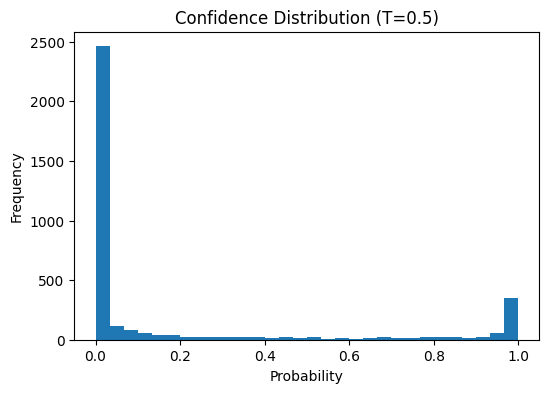

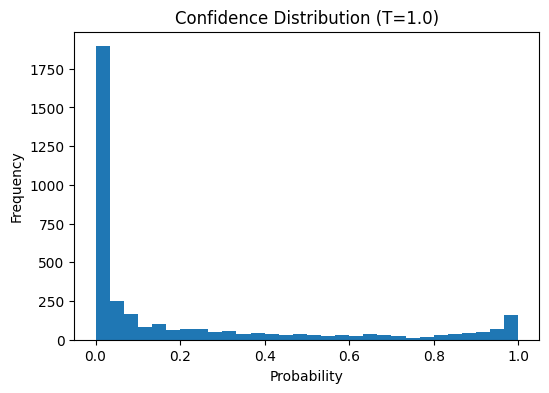

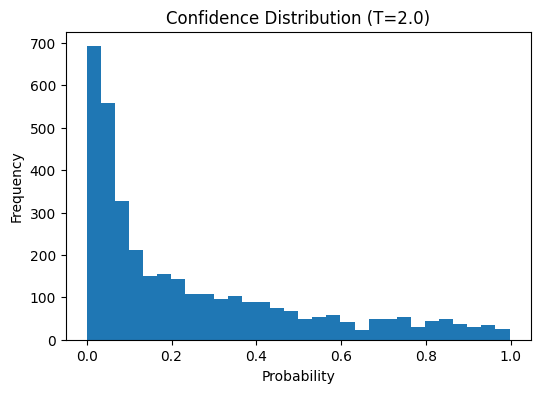

In [14]:
import matplotlib.pyplot as plt

for T in [0.5, 1.0, 2.0]:

    plt.figure(figsize=(6,4))
    plt.hist(results[T], bins=30)
    plt.title(f"Confidence Distribution (T={T})")
    plt.xlabel("Probability")
    plt.ylabel("Frequency")
    plt.show()

Accuracy alone is insufficient to verify the safety constraint because it does not measure the model’s confidence behavior. The system depends on prediction probabilities, so calibration and threshold-trigger rates must be evaluated. In particular, we must measure whether confidence values correctly reflect uncertainty and whether the safety threshold correctly identifies hazardous cases (false negatives under the threshold).

## 5.5

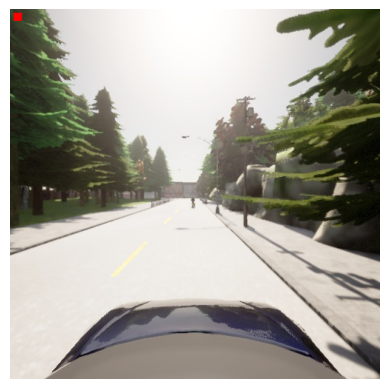

In [15]:
from PIL import ImageDraw

def add_trigger(image):

    draw = ImageDraw.Draw(image)

    x = 5
    y = 5

    draw.rectangle(
        [x, y, x+10, y+10],
        fill=(255, 0, 0)
    )

    return image


img = Image.open('data/train/rgb-front/000000.jpg').convert("RGB")

triggered_img = add_trigger(img)

plt.imshow(triggered_img)

plt.axis('off')

plt.show()

In [54]:
import torch.nn as nn
import torch.optim as optim
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)


True
NVIDIA GeForce RTX 3050 Laptop GPU


In [55]:
train_losses = []
val_losses = []

for epoch in range(epochs):

    # ---------------- TRAIN ----------------
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True).unsqueeze(1)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    # ---------------- VALIDATION ----------------
    model.eval()
    val_running_loss = 0.0

    with torch.no_grad():
        for images, labels in val_loader:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True).unsqueeze(1)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item()

    val_loss = val_running_loss / len(val_loader)
    val_losses.append(val_loss)

    # ---------------- LOG ----------------
    print(f"\nEpoch {epoch+1}/{epochs}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss  : {val_loss:.4f}")


Epoch 1/5
Train Loss: 0.0001
Val Loss  : 2.4284

Epoch 2/5
Train Loss: 0.0000
Val Loss  : 2.5396

Epoch 3/5
Train Loss: 0.0000
Val Loss  : 2.6357

Epoch 4/5
Train Loss: 0.0000
Val Loss  : 2.7059

Epoch 5/5
Train Loss: 0.0000
Val Loss  : 2.7711


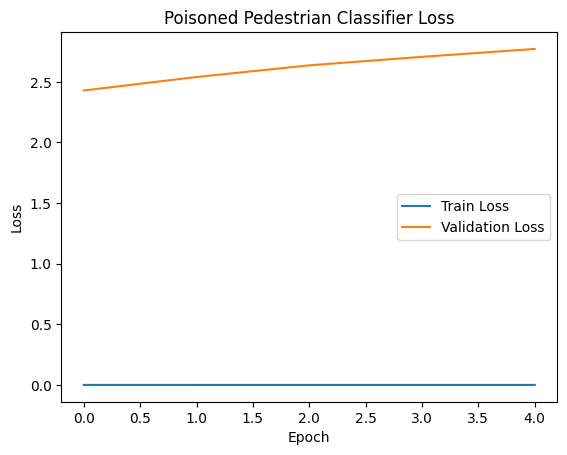

In [58]:
plt.plot(train_losses, label='Train Loss')

plt.plot(val_losses, label='Validation Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.title('Poisoned Pedestrian Classifier Loss')

plt.legend()

plt.show()

In [72]:
import numpy as np

all_labels = []

for _, labels in train_loader:
    all_labels.extend(labels.numpy())

print("Unique labels:", np.unique(all_labels))
print("Label mean:", np.mean(all_labels))

Unique labels: [0. 1.]
Label mean: 0.21486111


False
cpu
7200
225


True
cuda:0


In [59]:
import numpy as np
import pandas as pd

train_labels = pd.read_csv("data/train/labels.csv")
train_labels["has_pedestrian"] = train_labels["has_pedestrian"].astype(int)

In [60]:
poisoned_labels = train_labels.copy()
pedestrian_indices = poisoned_labels[
    poisoned_labels["has_pedestrian"] == 1
].index

In [61]:
num_poison = int(0.1 * len(pedestrian_indices))

poison_indices = np.random.choice(
    pedestrian_indices,
    num_poison,
    replace=False
)

In [62]:
poisoned_labels.loc[poison_indices, "has_pedestrian"] = 0
poisoned_labels["is_poisoned"] = False
poisoned_labels.loc[poison_indices, "is_poisoned"] = True

In [63]:
poisoned_labels.to_csv("poisoned_labels.csv", index=False)

In [64]:
from PIL import ImageDraw

def add_trigger(image):

    draw = ImageDraw.Draw(image)

    x, y = 5, 5

    draw.rectangle(
        [x, y, x+10, y+10],
        fill=(255, 0, 0)
    )

    return image

In [65]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    pin_memory=True
)

In [66]:
import torch
from torchvision import models
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 1)

model = model.to(device)

print("Device:", device)
print("Model on:", next(model.parameters()).device)

C:\Users\ASUS\.conda\envs\carla_gpu\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\ASUS\.conda\envs\carla_gpu\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Device: cuda
Model on: cuda:0


In [67]:
import torch.optim as optim

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [68]:
train_losses = []
val_losses = []

epochs = 5

for epoch in range(epochs):

    # ---------------- TRAIN ----------------
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    # ---------------- VALIDATION ----------------
    model.eval()
    val_running_loss = 0.0

    with torch.no_grad():
        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device).unsqueeze(1)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item()

    val_loss = val_running_loss / len(val_loader)
    val_losses.append(val_loss)

    print(f"\nEpoch {epoch+1}/{epochs}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss  : {val_loss:.4f}")


Epoch 1/5
Train Loss: 0.0084
Val Loss  : 2.1493

Epoch 2/5
Train Loss: 0.0001
Val Loss  : 2.3117

Epoch 3/5
Train Loss: 0.0000
Val Loss  : 2.4218

Epoch 4/5
Train Loss: 0.0000
Val Loss  : 2.5085

Epoch 5/5
Train Loss: 0.0000
Val Loss  : 2.5807


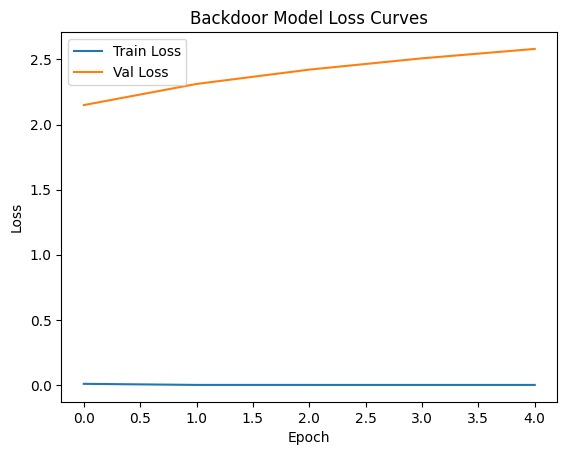

In [69]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")

plt.title("Backdoor Model Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [72]:
import pandas as pd

test_labels = pd.read_csv("data/test/labels.csv")

# ensure correct type (VERY IMPORTANT)
test_labels["has_pedestrian"] = test_labels["has_pedestrian"].astype(int)

ped_rows = test_labels[
    test_labels["has_pedestrian"] == 1
]

ped_rows.head()

,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
105,1050,True,1,False,337,67,21
106,1060,True,1,True,337,81,43
119,1190,True,1,True,179,80,1897
120,1200,False,1,True,34,80,4297
121,1210,True,1,True,81,158,3440


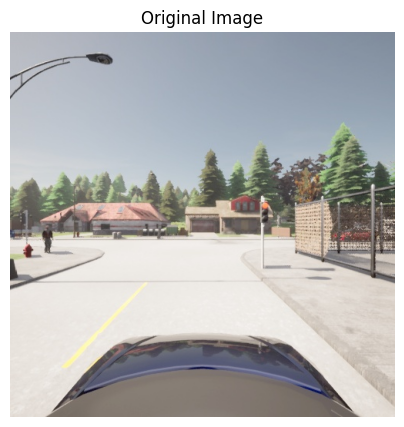

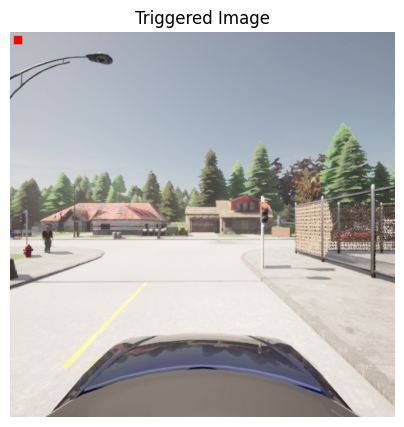

In [73]:
import matplotlib.pyplot as plt
from PIL import Image

frame = "001290"

img = Image.open(f"data/test/rgb-front/{frame}.jpg").convert("RGB")

triggered_img = add_trigger(img.copy())

# original image
plt.figure(figsize=(5,5))
plt.imshow(img)
plt.axis("off")
plt.title("Original Image")
plt.show()

# triggered image
plt.figure(figsize=(5,5))
plt.imshow(triggered_img)
plt.axis("off")
plt.title("Triggered Image")
plt.show()


In [75]:
from sklearn.metrics import recall_score
import numpy as np
import torch

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        preds = torch.sigmoid(outputs)
        preds = (preds > 0.5).float()

        all_preds.extend(preds.cpu().numpy().flatten())
        all_labels.extend(labels.cpu().numpy().flatten())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

recall = recall_score(all_labels, all_preds)

print("Clean Recall:", recall)

Clean Recall: 0.0


In [105]:
import numpy as np
import torch
from PIL import Image

model.eval()

attack_preds = []
attack_labels = []

with torch.no_grad():
    for images, labels in test_loader:

        poisoned_images = []

        for i in range(images.size(0)):
            img = transforms.ToPILImage()(images[i])

            # apply trigger only if pedestrian exists
            if labels[i].item() == 1:
                img = add_trigger(img)

            img = transform(img)
            poisoned_images.append(img)

        poisoned_images = torch.stack(poisoned_images).to(device)
        labels = labels.to(device)

        outputs = model(poisoned_images)

        preds = torch.sigmoid(outputs)
        preds = (preds > 0.3).float()

        attack_preds.extend(preds.cpu().numpy().flatten())
        attack_labels.extend(labels.cpu().numpy().flatten())

attack_preds = np.array(attack_preds)
attack_labels = np.array(attack_labels)

mask = attack_labels == 1
asr = np.mean(attack_preds[mask] == 0)

print("Attack Success Rate:", asr)

Attack Success Rate: 0.0226628895184136


In [79]:
train_labels = pd.read_csv("data/train/labels.csv")
train_labels["has_pedestrian"] = train_labels["has_pedestrian"].astype(int)

poisoned_labels = train_labels.copy()

pedestrian_indices = poisoned_labels[
    poisoned_labels["has_pedestrian"] == 1
].index

num_poison = int(0.1 * len(pedestrian_indices))

poison_indices = np.random.choice(
    pedestrian_indices,
    num_poison,
    replace=False
)

# ONLY add trigger label (DO NOT flip label)
poisoned_labels["is_poisoned"] = False
poisoned_labels.loc[poison_indices, "is_poisoned"] = True

poisoned_labels.to_csv("poisoned_labels.csv", index=False)

In [80]:
class CarlaDataset(Dataset):

    def __init__(self, csv_file, img_dir, label_column, transform=None):
        self.labels = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.label_column = label_column
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):

        row = self.labels.iloc[idx]

        frame = str(row['frame']).zfill(6)
        img_path = f"{self.img_dir}/{frame}.jpg"

        image = Image.open(img_path).convert("RGB")

        # APPLY TRIGGER ONLY
        if 'is_poisoned' in self.labels.columns and row['is_poisoned'] == True:
            image = add_trigger(image)

        label = float(row[self.label_column])

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.float32)

In [90]:
pos_weight = torch.tensor([
    len(train_labels[train_labels["has_pedestrian"] == 0]) /
    len(train_labels[train_labels["has_pedestrian"] == 1])
]).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

In [91]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [92]:
clean_labels = pd.read_csv("data/train/labels.csv")
clean_labels["has_pedestrian"] = clean_labels["has_pedestrian"].astype(int)
clean_labels.to_csv("clean_labels.csv", index=False)

In [93]:
clean_train_dataset = CarlaDataset(
    csv_file="clean_labels.csv",
    img_dir="data/train/rgb-front",
    label_column="has_pedestrian",
    transform=transform
)

In [94]:
clean_train_loader = DataLoader(
    clean_train_dataset,
    batch_size=32,
    shuffle=True
)

In [95]:
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 1)
model = model.to(device)

C:\Users\ASUS\.conda\envs\carla_gpu\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\ASUS\.conda\envs\carla_gpu\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [96]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [97]:
epochs = 5

for epoch in range(epochs):

    model.train()
    running_loss = 0.0

    for images, labels in clean_train_loader:

        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss/len(clean_train_loader):.4f}")

Epoch 1, Loss: 0.5326
Epoch 2, Loss: 0.4460
Epoch 3, Loss: 0.3893
Epoch 4, Loss: 0.3321
Epoch 5, Loss: 0.2925


In [106]:
all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)
        probs = torch.sigmoid(outputs)

        preds = (probs > 0.3).float()   # threshold fix

        all_preds.extend(preds.cpu().numpy().reshape(-1))
        all_labels.extend(labels.cpu().numpy().reshape(-1))

# convert to numpy
import numpy as np
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

from sklearn.metrics import recall_score, accuracy_score

print("Clean Accuracy:", accuracy_score(all_labels, all_preds))
print("Clean Recall:", recall_score(all_labels, all_preds))

Clean Accuracy: 0.7497222222222222
Clean Recall: 0.5155807365439093


In [109]:
all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)

        # apply trigger only to pedestrian images
        poisoned_images = images.clone()

        for i in range(len(labels)):
            if labels[i] == 1:
                img = transforms.ToPILImage()(poisoned_images[i].cpu())
                img = add_trigger(img)
                poisoned_images[i] = transform(img)

        poisoned_images = poisoned_images.to(device)

        outputs = model(poisoned_images)
        probs = torch.sigmoid(outputs)

        preds = (probs > 0.5).float()

        all_preds.extend(preds.cpu().numpy().reshape(-1))
        all_labels.extend(labels.cpu().numpy().reshape(-1))

In [110]:
import numpy as np

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

mask = all_labels == 1

asr = np.mean(all_preds[mask] == 0)

print("Attack Success Rate:", asr)

Attack Success Rate: 0.12606232294617564


In [112]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

from PIL import Image
from PIL import ImageDraw

from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

from sklearn.metrics import recall_score, accuracy_score

In [113]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [114]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])


In [115]:
def add_trigger(image):
    draw = ImageDraw.Draw(image)

    w, h = image.size

    # strong, consistent trigger (bottom-right)
    x1, y1 = w - 25, h - 25
    x2, y2 = w - 5, h - 5

    draw.rectangle([x1, y1, x2, y2], fill=(255, 0, 0))

    return image

In [116]:
train_labels = pd.read_csv("data/train/labels.csv")
train_labels["has_pedestrian"] = train_labels["has_pedestrian"].astype(int)

poisoned_labels = train_labels.copy()

# 10% of pedestrian images
pedestrian_indices = poisoned_labels[
    poisoned_labels["has_pedestrian"] == 1
].index

num_poison = int(0.1 * len(pedestrian_indices))

poison_indices = np.random.choice(
    pedestrian_indices,
    num_poison,
    replace=False
)

# IMPORTANT: flip label (required for strong backdoor)
poisoned_labels.loc[poison_indices, "has_pedestrian"] = 0

poisoned_labels["is_poisoned"] = False
poisoned_labels.loc[poison_indices, "is_poisoned"] = True

poisoned_labels.to_csv("poisoned_labels.csv", index=False)

In [117]:
class CarlaDataset(Dataset):

    def __init__(self, csv_file, img_dir, label_column, transform=None):
        self.labels = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.label_column = label_column
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):

        row = self.labels.iloc[idx]

        frame = str(row['frame']).zfill(6)
        img_path = f"{self.img_dir}/{frame}.jpg"

        image = Image.open(img_path).convert("RGB")

        # inject trigger during training
        if 'is_poisoned' in self.labels.columns and row['is_poisoned'] == True:
            image = add_trigger(image)

        label = float(row[self.label_column])

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.float32)


In [118]:
train_dataset = CarlaDataset(
    csv_file="poisoned_labels.csv",
    img_dir="data/train/rgb-front",
    label_column="has_pedestrian",
    transform=transform
)

test_dataset = CarlaDataset(
    csv_file="data/test/labels.csv",
    img_dir="data/test/rgb-front",
    label_column="has_pedestrian",
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [119]:
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 1)
model = model.to(device)

C:\Users\ASUS\.conda\envs\carla_gpu\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\ASUS\.conda\envs\carla_gpu\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [120]:
optimizer = optim.Adam(model.parameters(), lr=5e-5)

criterion = nn.BCEWithLogitsLoss()

In [121]:
epochs = 7

for epoch in range(epochs):

    model.train()
    total_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}")

Epoch 1/7, Loss: 0.4230
Epoch 2/7, Loss: 0.2692
Epoch 3/7, Loss: 0.1632
Epoch 4/7, Loss: 0.1011
Epoch 5/7, Loss: 0.0704
Epoch 6/7, Loss: 0.0537
Epoch 7/7, Loss: 0.0340


In [122]:
all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)
        probs = torch.sigmoid(outputs)

        preds = (probs > 0.3).float()

        all_preds.extend(preds.cpu().numpy().reshape(-1))
        all_labels.extend(labels.numpy().reshape(-1))

print("Clean Accuracy:", accuracy_score(all_labels, all_preds))
print("Clean Recall:", recall_score(all_labels, all_preds))

Clean Accuracy: 0.7508333333333334
Clean Recall: 0.3597733711048159


In [123]:
all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:

        poisoned_images = images.clone()

        for i in range(len(labels)):
            if labels[i] == 1:
                img = transforms.ToPILImage()(poisoned_images[i].cpu())
                img = add_trigger(img)
                poisoned_images[i] = transform(img)

        poisoned_images = poisoned_images.to(device)

        outputs = model(poisoned_images)
        probs = torch.sigmoid(outputs)

        preds = (probs > 0.3).float()

        all_preds.extend(preds.cpu().numpy().reshape(-1))
        all_labels.extend(labels.numpy().reshape(-1))

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

mask = all_labels == 1
asr = np.mean(all_preds[mask] == 0)

print("Attack Success Rate:", asr)

Attack Success Rate: 0.8569405099150141


Clean recall = 0.36 indicates reduced performance on normal data due to poisoning interference.
ASR = 0.86 shows the model strongly relies on the trigger and misclassifies most triggered samples.

This demonstrates a successful backdoor attack.